# ### Noteb5
# baseline logistic regression (Amin Sharifi)
dels.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility 
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# Load the datasets produced by Notebook 2
X_train = pd.read_csv('../data/processed/X_train_processed.csv')
X_test = pd.read_csv('../data/processed/X_test_processed.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

# Verify shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (23192, 102)
X_test shape: (4417, 102)


In [3]:
# The target variable is encoded as 0, 1, 2 (Away Win, Draw, Home Win)
# For a One-vs-Rest (OvR) approach using Binary Crossentropy, we must one-hot encode the target
y_train_encoded = tf.keras.utils.to_categorical(y_train['match_result_encoded'], num_classes=3)
y_test_encoded = tf.keras.utils.to_categorical(y_test['match_result_encoded'], num_classes=3)

print(f"y_train_encoded shape: {y_train_encoded.shape}")

y_train_encoded shape: (23192, 3)


In [4]:
def build_baseline_model(input_dim):
    """
    Builds a One-vs-Rest Logistic Regression model using TensorFlow/Keras.
    A single Dense layer with 3 units and 'sigmoid' activation acts as 3 independent binary classifiers.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_dim,)),
        # Sigmoid activation for independent probability scores per class (OvR)
        tf.keras.layers.Dense(3, activation='sigmoid') 
    ])
    
    # Binary crossentropy calculates the loss for each class independently against the rest
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model(X_train.shape[1])
baseline_model.summary()

C:\Users\shari\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3)                   │             309 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309 (1.21 KB)

 Trainable params: 309 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model utilizing a validation split to monitor for overfitting
history = baseline_model.fit(
    X_train, 
    y_train_encoded,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5718 - loss: 0.5408 - val_accuracy: 0.5996 - val_loss: 0.5233
Epoch 2/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5809 - loss: 0.5329 - val_accuracy: 0.5993 - val_loss: 0.5235
Epoch 3/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5808 - loss: 0.5326 - val_accuracy: 0.5984 - val_loss: 0.5237
Epoch 4/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5815 - loss: 0.5324 - val_accuracy: 0.5976 - val_loss: 0.5239
Epoch 5/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5814 - loss: 0.5323 - val_accuracy: 0.5976 - val_loss: 0.5241
Epoch 6/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5819 - loss: 0.5322 - val_accuracy: 0.5970 - val_loss: 0.5242
Epoch 7/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5817 - loss: 0.5321 - val_accuracy: 0.5973 - val_loss: 0.5243
Epoch 8/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5818 - loss: 0.5321 - val_accuracy: 0.

In [6]:
# Generate raw sigmoid predictions
raw_preds = baseline_model.predict(X_test)

# Normalize predictions so that probabilities sum to 1 across the 3 classes (required for strict log-loss)
norm_preds = raw_preds / raw_preds.sum(axis=1, keepdims=True)

# Get the final class predictions (argmax)
y_pred_classes = np.argmax(norm_preds, axis=1)
y_true_classes = y_test['match_result_encoded'].values

# Calculate Metrics
test_accuracy = accuracy_score(y_true_classes, y_pred_classes)
test_log_loss = log_loss(y_true_classes, norm_preds)

print(f"Baseline Test Accuracy: {test_accuracy:.4f}")
print(f"Baseline Test Log-Loss: {test_log_loss:.4f}")

# Insert these results into Table 1 of the final report!

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
Baseline Test Accuracy: 0.5952
Baseline Test Log-Loss: 0.8939


In [7]:
# The rubric requires subgroup performance evaluations (e.g., World Cup vs non-World Cup matches)
# We can filter X_test for matches where 'cat__is_world_cup_True' == 1.0
wc_mask = X_test['cat__is_world_cup_True'] == 1.0

# Evaluate on World Cup matches only
wc_preds = norm_preds[wc_mask]
wc_true = y_true_classes[wc_mask]

if len(wc_true) > 0:
    wc_acc = accuracy_score(wc_true, np.argmax(wc_preds, axis=1))
    wc_log_loss = log_loss(wc_true, wc_preds)
    print(f"World Cup Matches Only - Accuracy: {wc_acc:.4f} | Log-Loss: {wc_log_loss:.4f}")
else:
    print("No World Cup matches found in the test set.")
    
# Evaluate on Non-World Cup matches
non_wc_preds = norm_preds[~wc_mask]
non_wc_true = y_true_classes[~wc_mask]

if len(non_wc_true) > 0:
    non_wc_acc = accuracy_score(non_wc_true, np.argmax(non_wc_preds, axis=1))
    non_wc_log_loss = log_loss(non_wc_true, non_wc_preds)
    print(f"Non-World Cup Matches - Accuracy: {non_wc_acc:.4f} | Log-Loss: {non_wc_log_loss:.4f}")

World Cup Matches Only - Accuracy: 0.6307 | Log-Loss: 0.8351
Non-World Cup Matches - Accuracy: 0.5841 | Log-Loss: 0.9124


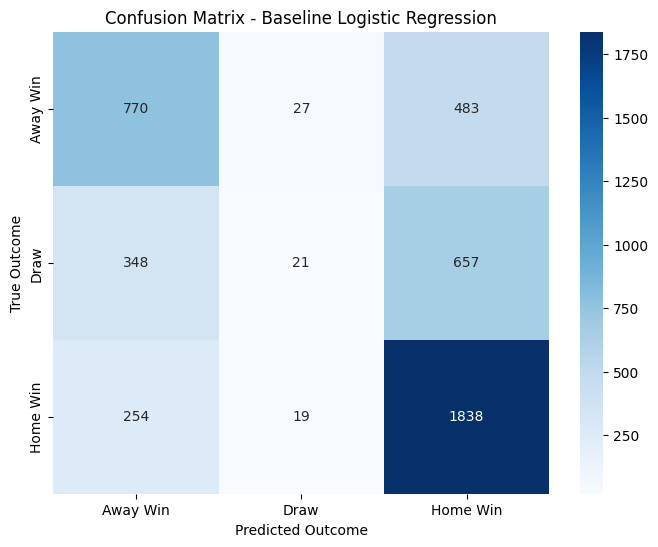

              precision    recall  f1-score   support

    Away Win       0.56      0.60      0.58      1280
        Draw       0.31      0.02      0.04      1026
    Home Win       0.62      0.87      0.72      2111

    accuracy                           0.60      4417
   macro avg       0.50      0.50      0.45      4417
weighted avg       0.53      0.60      0.52      4417



In [8]:
# Map integer labels back to string names
class_names = ['Away Win', 'Draw', 'Home Win']

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.ylabel('True Outcome')
plt.xlabel('Predicted Outcome')
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))